In [ ]:

import numpy as np
from matplotlib import pyplot as plt
from dataclasses import dataclass
from echospec.utils.parameters import Parameters
from echospec.experiments.spectroscopy_vs_amplitude import AmplitudeSweepSpectroscopy, OptionsSpectroscopy2d
from echospec.utils.units import Units as u

from echospec.simulation.torry import find_fwhm_vec_vs_rabi
plt.style.use("paper.mplstyle")


# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------
def run_spectroscopy(
    *,
    amplitudes,
    detunings,
    eco_pulse: bool,
    noise: float,
    num_time_points: int = 1000,
    cutoff: float = 0.05,
    pulse_length=50e-6

):
    options = OptionsSpectroscopy2d(
        plot=False,
        num_time_points=num_time_points,
        noise=noise,
        
    )

    params = Parameters()
    params.eco_pulse = eco_pulse
    params.cutoff = cutoff
    params.pulse_length = pulse_length

    experiment = AmplitudeSweepSpectroscopy(
        amplitudes=amplitudes,
        detunings=detunings,
        params=params,
        options=options,
    )

    return experiment.run()


amplitudes = np.linspace(
    0,
    80 * u.pi2 * u.MHz,
    40,
)

detunings = np.linspace(
    -0.1 * u.pi2 * u.MHz,
    +0.1 * u.pi2 * u.MHz,
    41,
)

: 

In [2]:
noise = 0.05
pulse_length = 10e-6
echo_pulse = True
# ------------------------------------------------------------
# Runs
# ------------------------------------------------------------
def short_cut(cutoff):
    return run_spectroscopy(
        amplitudes=amplitudes,
        detunings=detunings,
        eco_pulse=echo_pulse,
        noise=noise,
        cutoff=cutoff,
        pulse_length=pulse_length
    )

results_clean = {
    "c1": short_cut(cutoff=1e-4),
    # "c2": short_cut(cutoff=2e-4),
    # "c3": short_cut(cutoff=5e-4),
    # "c4": short_cut(cutoff=1e-3),
    # "c5": short_cut(cutoff=2e-3),
    # "c6": short_cut(cutoff=5e-3),
}




Amplitude sweep:   0%|          | 0/40 [00:00<?, ?Ω/s]

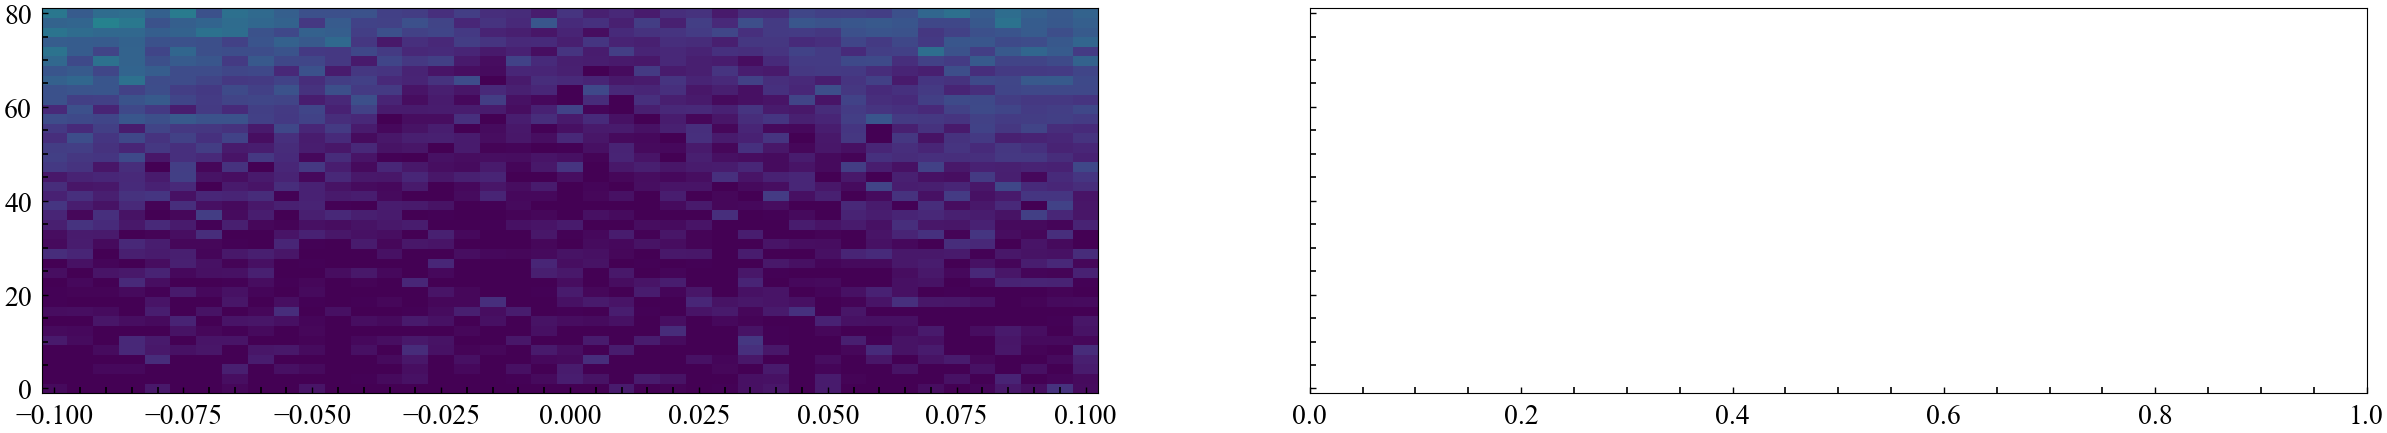

In [5]:
fig,axes = plt.subplots(1, 2, figsize=(15, 2.5), sharey=True)

for idx, (key, result) in enumerate(results_clean.items()):
    ax = axes[idx]
    x = result.amplitudes
    y = result.detunings
    z = result.populations
    # # Extract the spectroscopy data (assuming the magnitude or real part)
    # data = result.states
    
    # # Create pcolormesh
    mesh = ax.pcolormesh(
        detunings / (2 * np.pi * u.MHz), 
        amplitudes / (2 * np.pi * u.MHz), 
        z,
        shading='auto',
        cmap='viridis',
        vmin=0,
        vmax=0.5
    )
    # ax.set_ylim([0,50])
    # ax.axvline(T2_limit / 2/1e6, color='gray', linestyle='--', label='T2 limit')
    # ax.axvline(-T2_limit / 2/1e6, color='gray', linestyle='--', label='T2 limit')